In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yastn
from yastn.tn import mps

import os
import glob

from scripts_fermions.operators import project_Ln, L_to_t
from sklearn.decomposition import PCA


from scipy.special import jv, gammaincc, gamma
from scipy.optimize import minimize

In [2]:
N, a, x0, sg2 = 256, 0.125, 3.0, 0.25
fname = f"./Proj_Gaussian_{N=}_{a=:0.4f}.npy"
PRs = np.load(fname, allow_pickle=True).item()

ts = np.linspace(0, N * a / 2, 9)
LLs = np.array([-2, -3/2, -1, -1/2, 0, 1/2, 1, 3/2, 2])

Nas = [(256, 0.125)] # [(256, 0.125), (512, 0.0625), (512, 0.125)]
ms = [0.0, 0.5]
g = 1
sg2s = [0.0625, 0.25]
x0s = [1.5, 3.0]
Ps = [0, 1, 2, 3, 4]
Ds = [256,]


In [3]:
def get_probability(x0, sg2, m, P, D):
    pls_mid = np.zeros((len(ts), len(LLs)))
    for i, t in enumerate(ts):
        for j, x in enumerate(PRs[x0, sg2, m, P, D, t]):
           pls_mid[i, j] = x['pr']
    return pls_mid

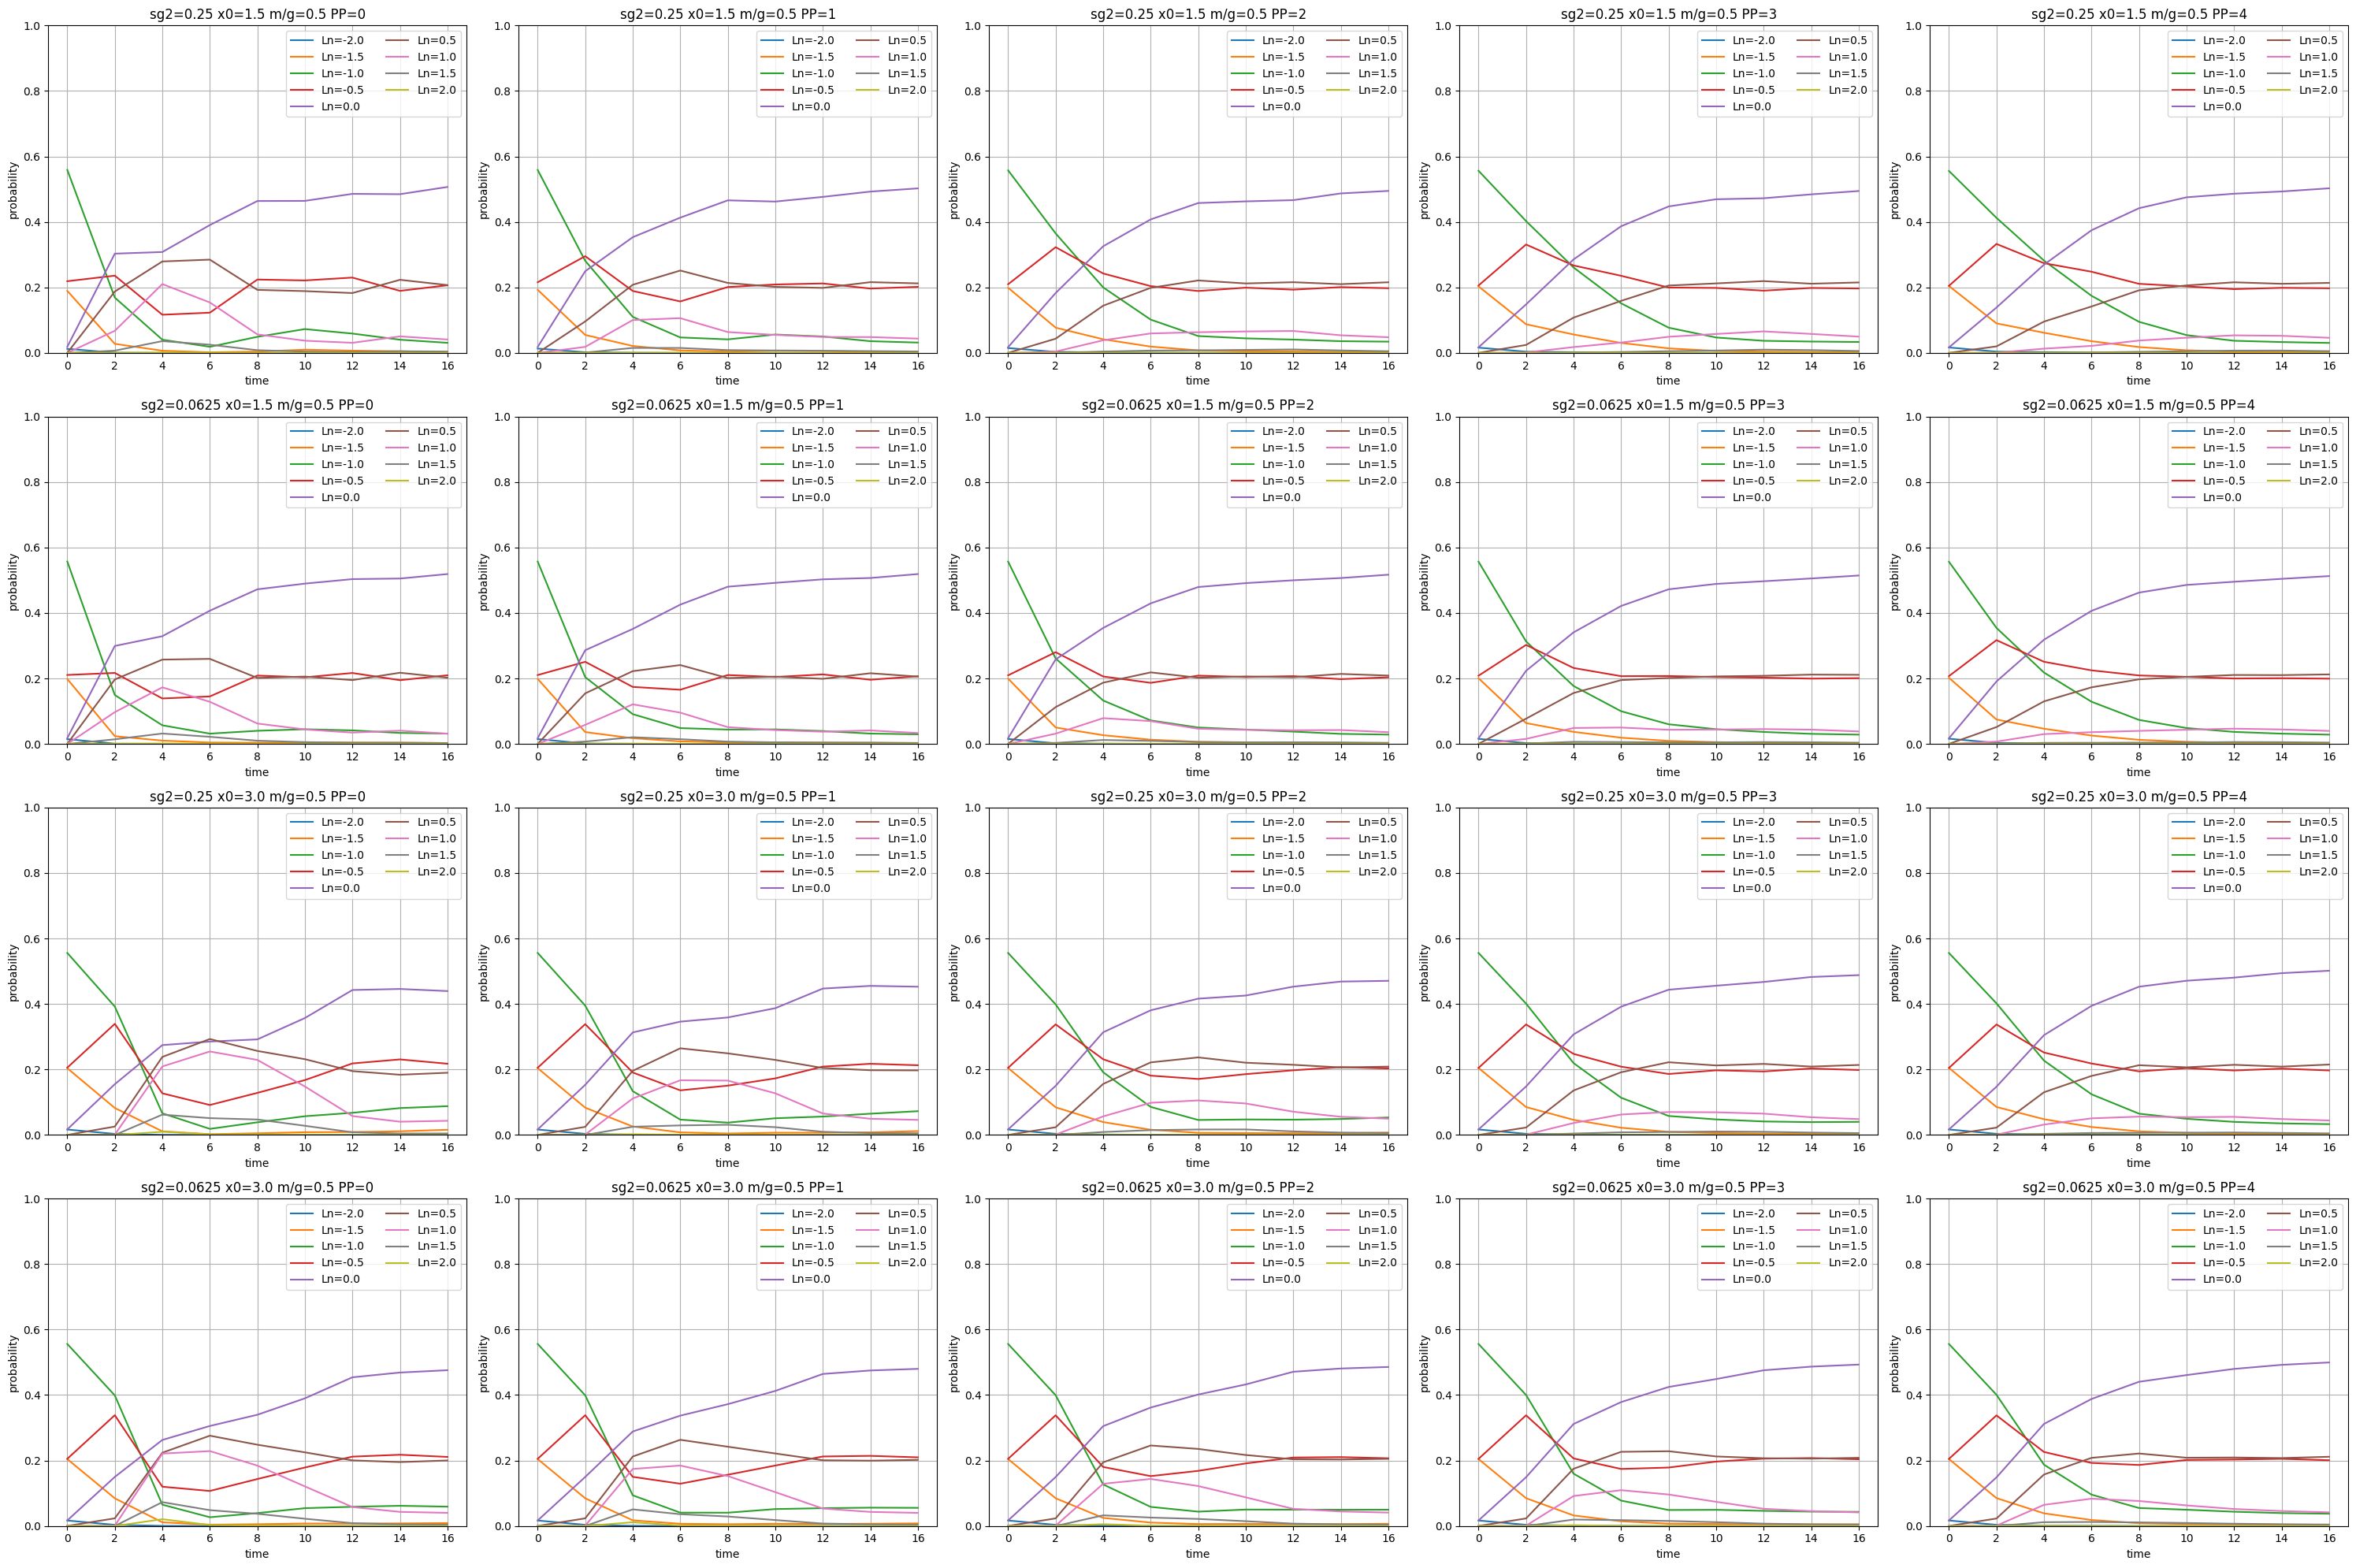

In [4]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]
PPs = np.linspace(0, 6, 49)

# sg2x0s = [(0.5, 1.5), (0.25, 1.5), (0.5, 3.0), (0.125, 1.5), (0.25, 3.0), (0.0625, 1.5), (0.125, 3.0), (0.0625, 3.0), (0.25, 6.0), (0.25, 9.0)]

sg2x0s = [(0.25, 1.5), (0.0625, 1.5), (0.25, 3.0), (0.0625, 3.0)]
Ps = [0, 1, 2, 3, 4]

D = 256
m = 0.5
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]
fig, axs = plt.subplots(len(sg2x0s), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(sg2x0s) * 5)
for ii, (sg2, x0) in enumerate(sg2x0s):
  for jj, PP in enumerate(Ps):
      pls_mid = get_probability(x0, sg2, m, PP, D)
      for kk, l in enumerate(LLs):
        axs[ii,jj].plot(ts[slc], pls_mid[slc, kk], label=f'Ln={l}')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 1)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('probability')
      axs[ii,jj].set_title(f"{sg2=} {x0=} {m/g=} {PP=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


Text(0, 0.5, 'Dominant PCA weight')

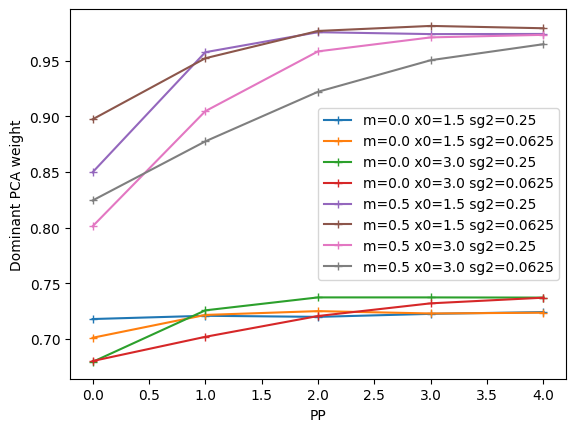

In [5]:
pca = PCA()

for m in ms:
    for ii, (sg2, x0) in enumerate(sg2x0s):

        dom = []

        for PP in Ps:
            pls_mid = get_probability(x0, sg2, m, PP, D)
            pca.fit(pls_mid[slc])
            y = pca.explained_variance_ratio_[0]
            dom.append(y)
        plt.plot(Ps, dom, '-+', label=f"{m=} {x0=} {sg2=}")
plt.legend()
plt.xlabel("PP")
plt.ylabel("Dominant PCA weight")

In [6]:
def dominant_component(ax, x0, sg2, m, PP, D):
    pls_mid = get_probability(x0, sg2, m, PP, D)
    pcaproj = PCA(n_components=1)
    pcaproj.fit(pls_mid[slc])
    pcacomp = pcaproj.transform(pls_mid[slc])


    def f(b, al, tau):
        return gammaincc(1+al, b*tau**2)

    y = pcacomp[:, 0]
    t = ts[slc]

    def mse(pars):
        c, b, a = pars
        return np.mean((y + a - c * f(b, 0, t)) ** 2)

    x0 = (0.57, 0.06, 0.1)
    sol = minimize(mse, x0)

    c, b, a = sol.x

    ax.plot(t, pcacomp, 'o-', alpha=0.5, label='first PCA component')
    tf = np.linspace(0, ts[-1], 500)
    ax.plot(tf, c * f(b, 0, tf) - a, label='Lund-like gaussian fit')
    ax.grid()
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('f(t)')
    ax.set_xlim(0, ts[-1])
    ax.set_ylim(-0.2, 1)
    ax.set_title(f"{sg2=} {x0=} {m/g=} {PP=}")
    ax.text(ts[-1] /2, 0.6, f"{a=:0.3f} {b=:0.3f} {c=:0.3f}")

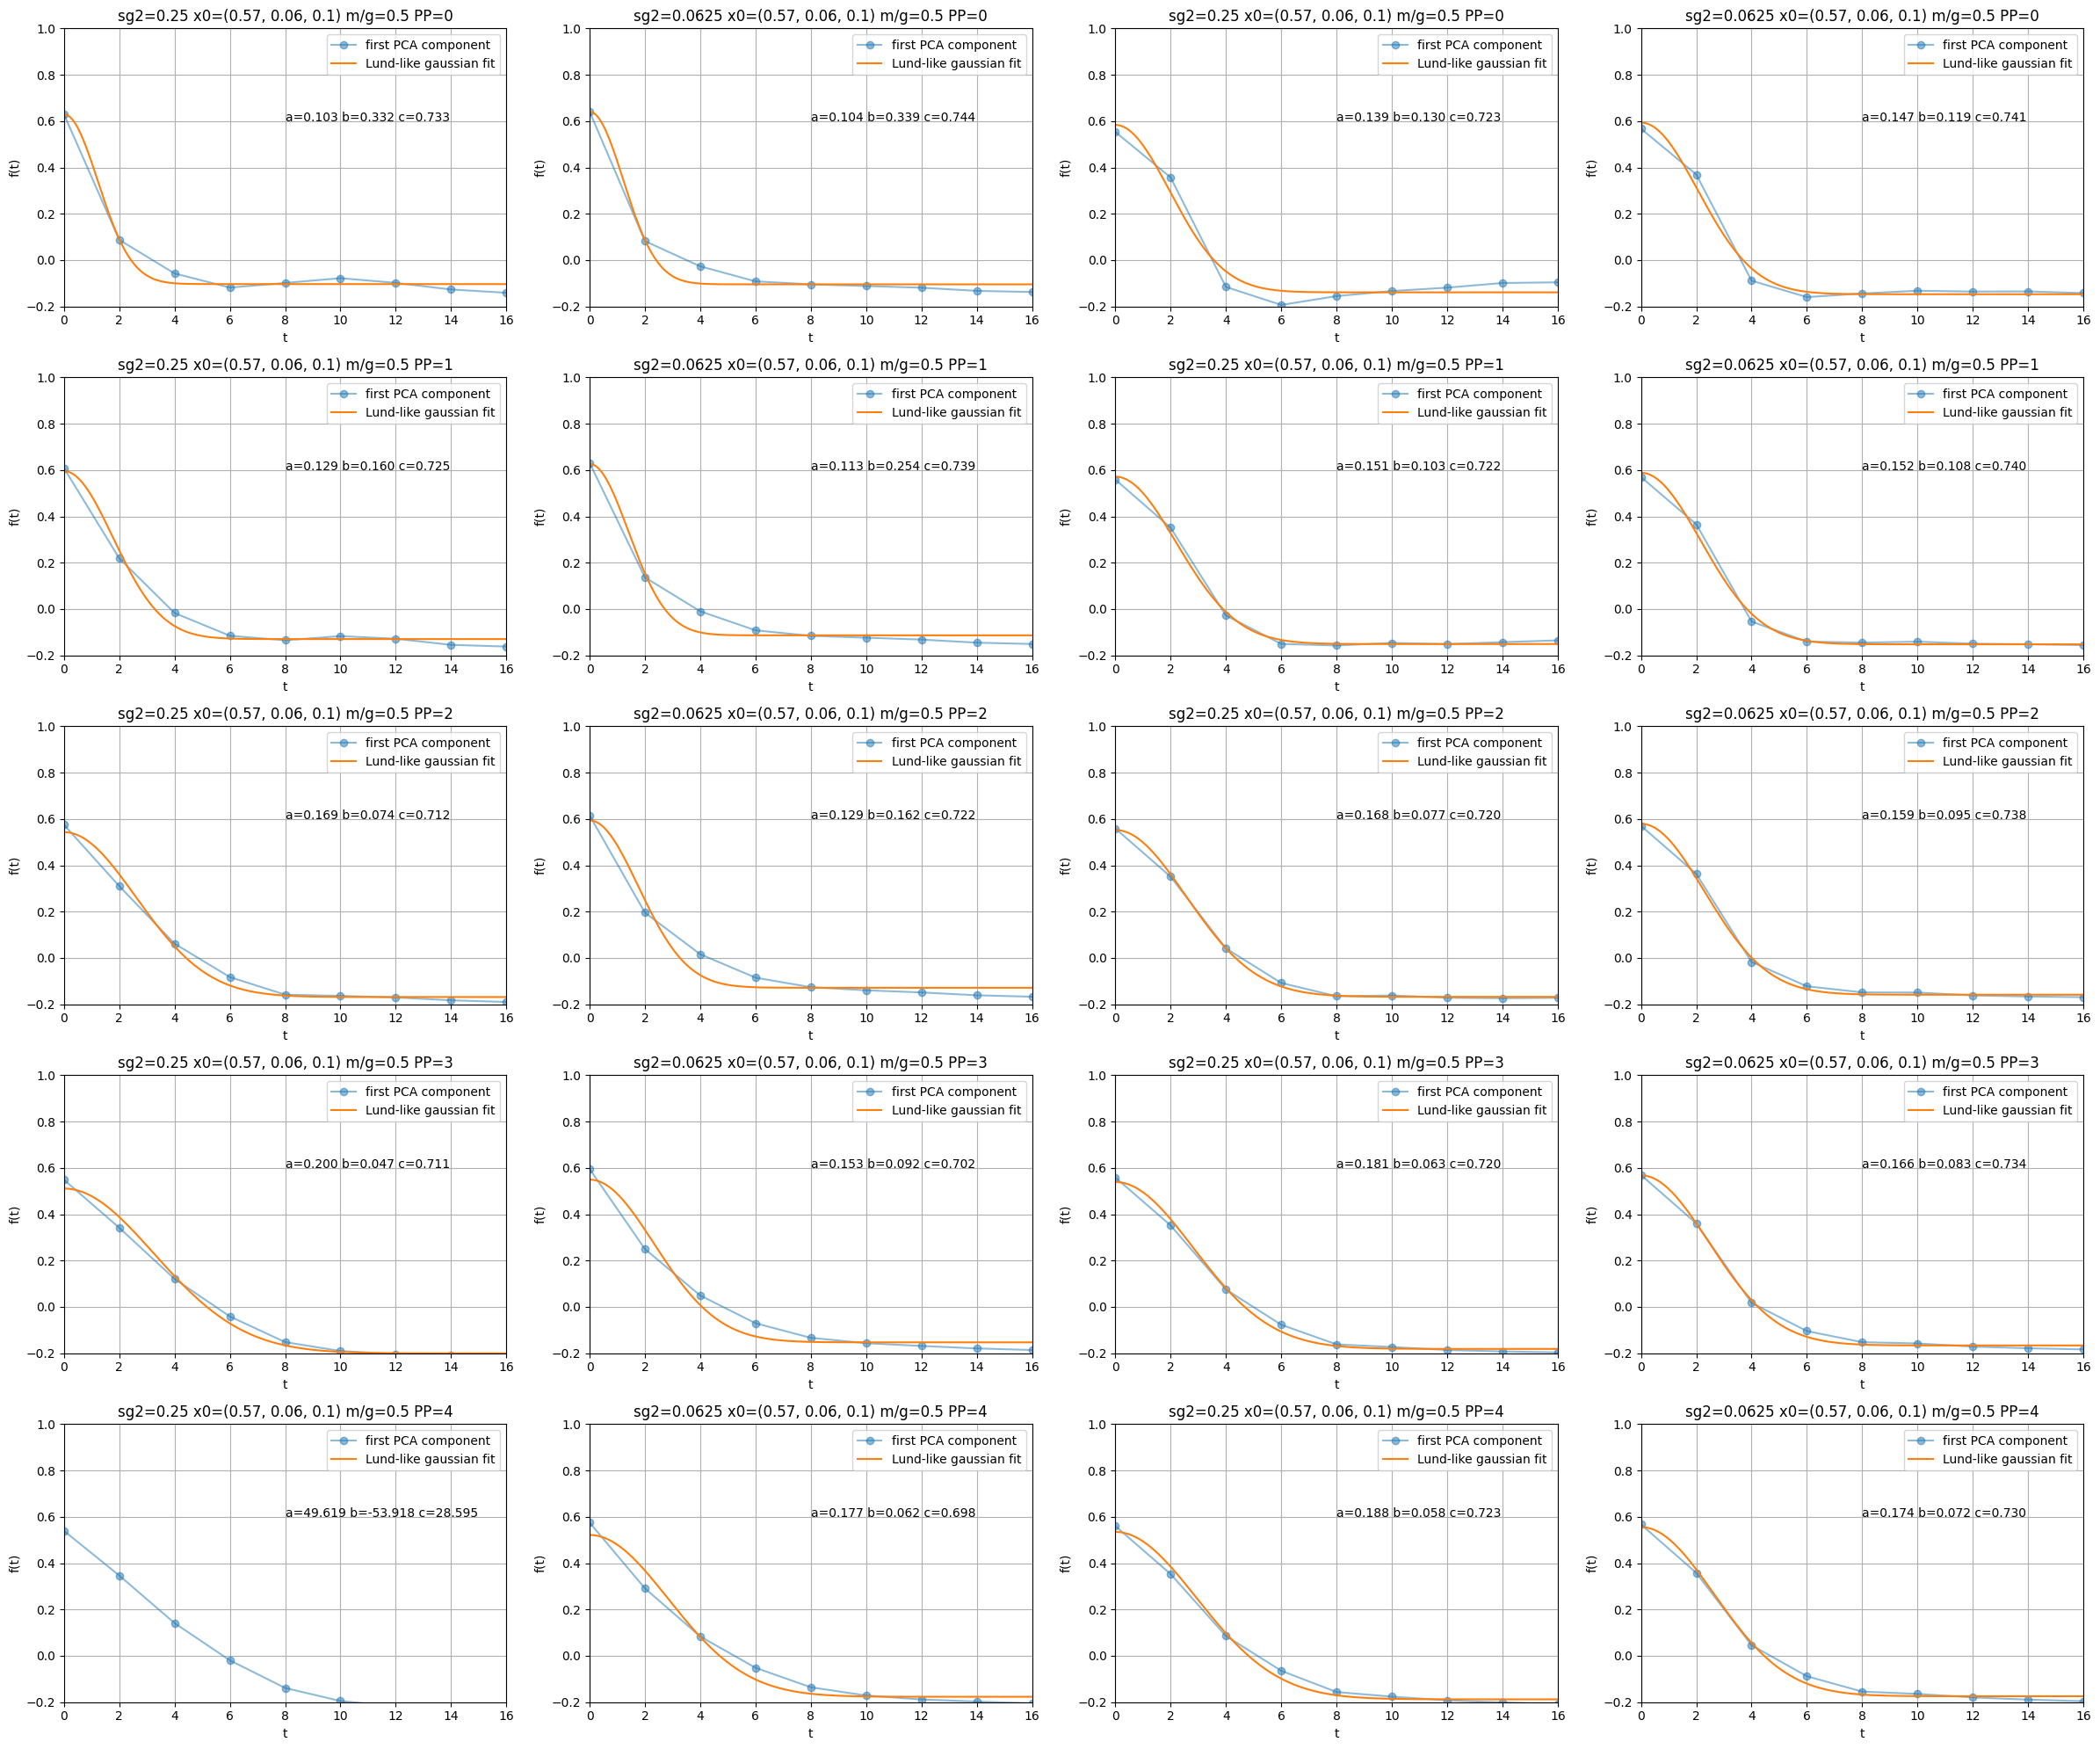

In [7]:
cm = plt.cm.jet
fig, axs = plt.subplots(len(Ps), len(sg2x0s), squeeze=False)
fig.set_size_inches(len(sg2x0s) * 6, len(Ps) * 4)
slc = slice(None)

D = 256
m = 0.5
for ii, PP in enumerate(Ps):
  for jj, (sg2, x0) in enumerate(sg2x0s):
      dominant_component(axs[ii, jj], x0, sg2, m, PP, D)

fig.tight_layout()

In [17]:
def get_ent(x0, sg2, m, P, D, normalize = False):
    tmp = np.zeros((len(ts), len(LLs)))
    for i, t in enumerate(ts):
        for j, x in enumerate(PRs[x0, sg2, m, P, D, t]):
           v = x['SL']['data']
           if normalize:
               v = v / np.sqrt(sum(v ** 2))
           tmp[i, j] = -2 * sum(v * v * np.log2(v))
    return tmp

In [28]:
def get_sv(x0, sg2, m, P, D, normalize = False, num=4):
    tmp = np.zeros((len(ts), 20))
    for i, t in enumerate(ts):
        v = PRs[x0, sg2, m, P, D, t][num]['SL']['data']
        lv = min(len(v), 20)
        if normalize:
            v = v / np.sqrt(sum(v ** 2))
        tmp[i, :lv] = v[:lv]
    return tmp

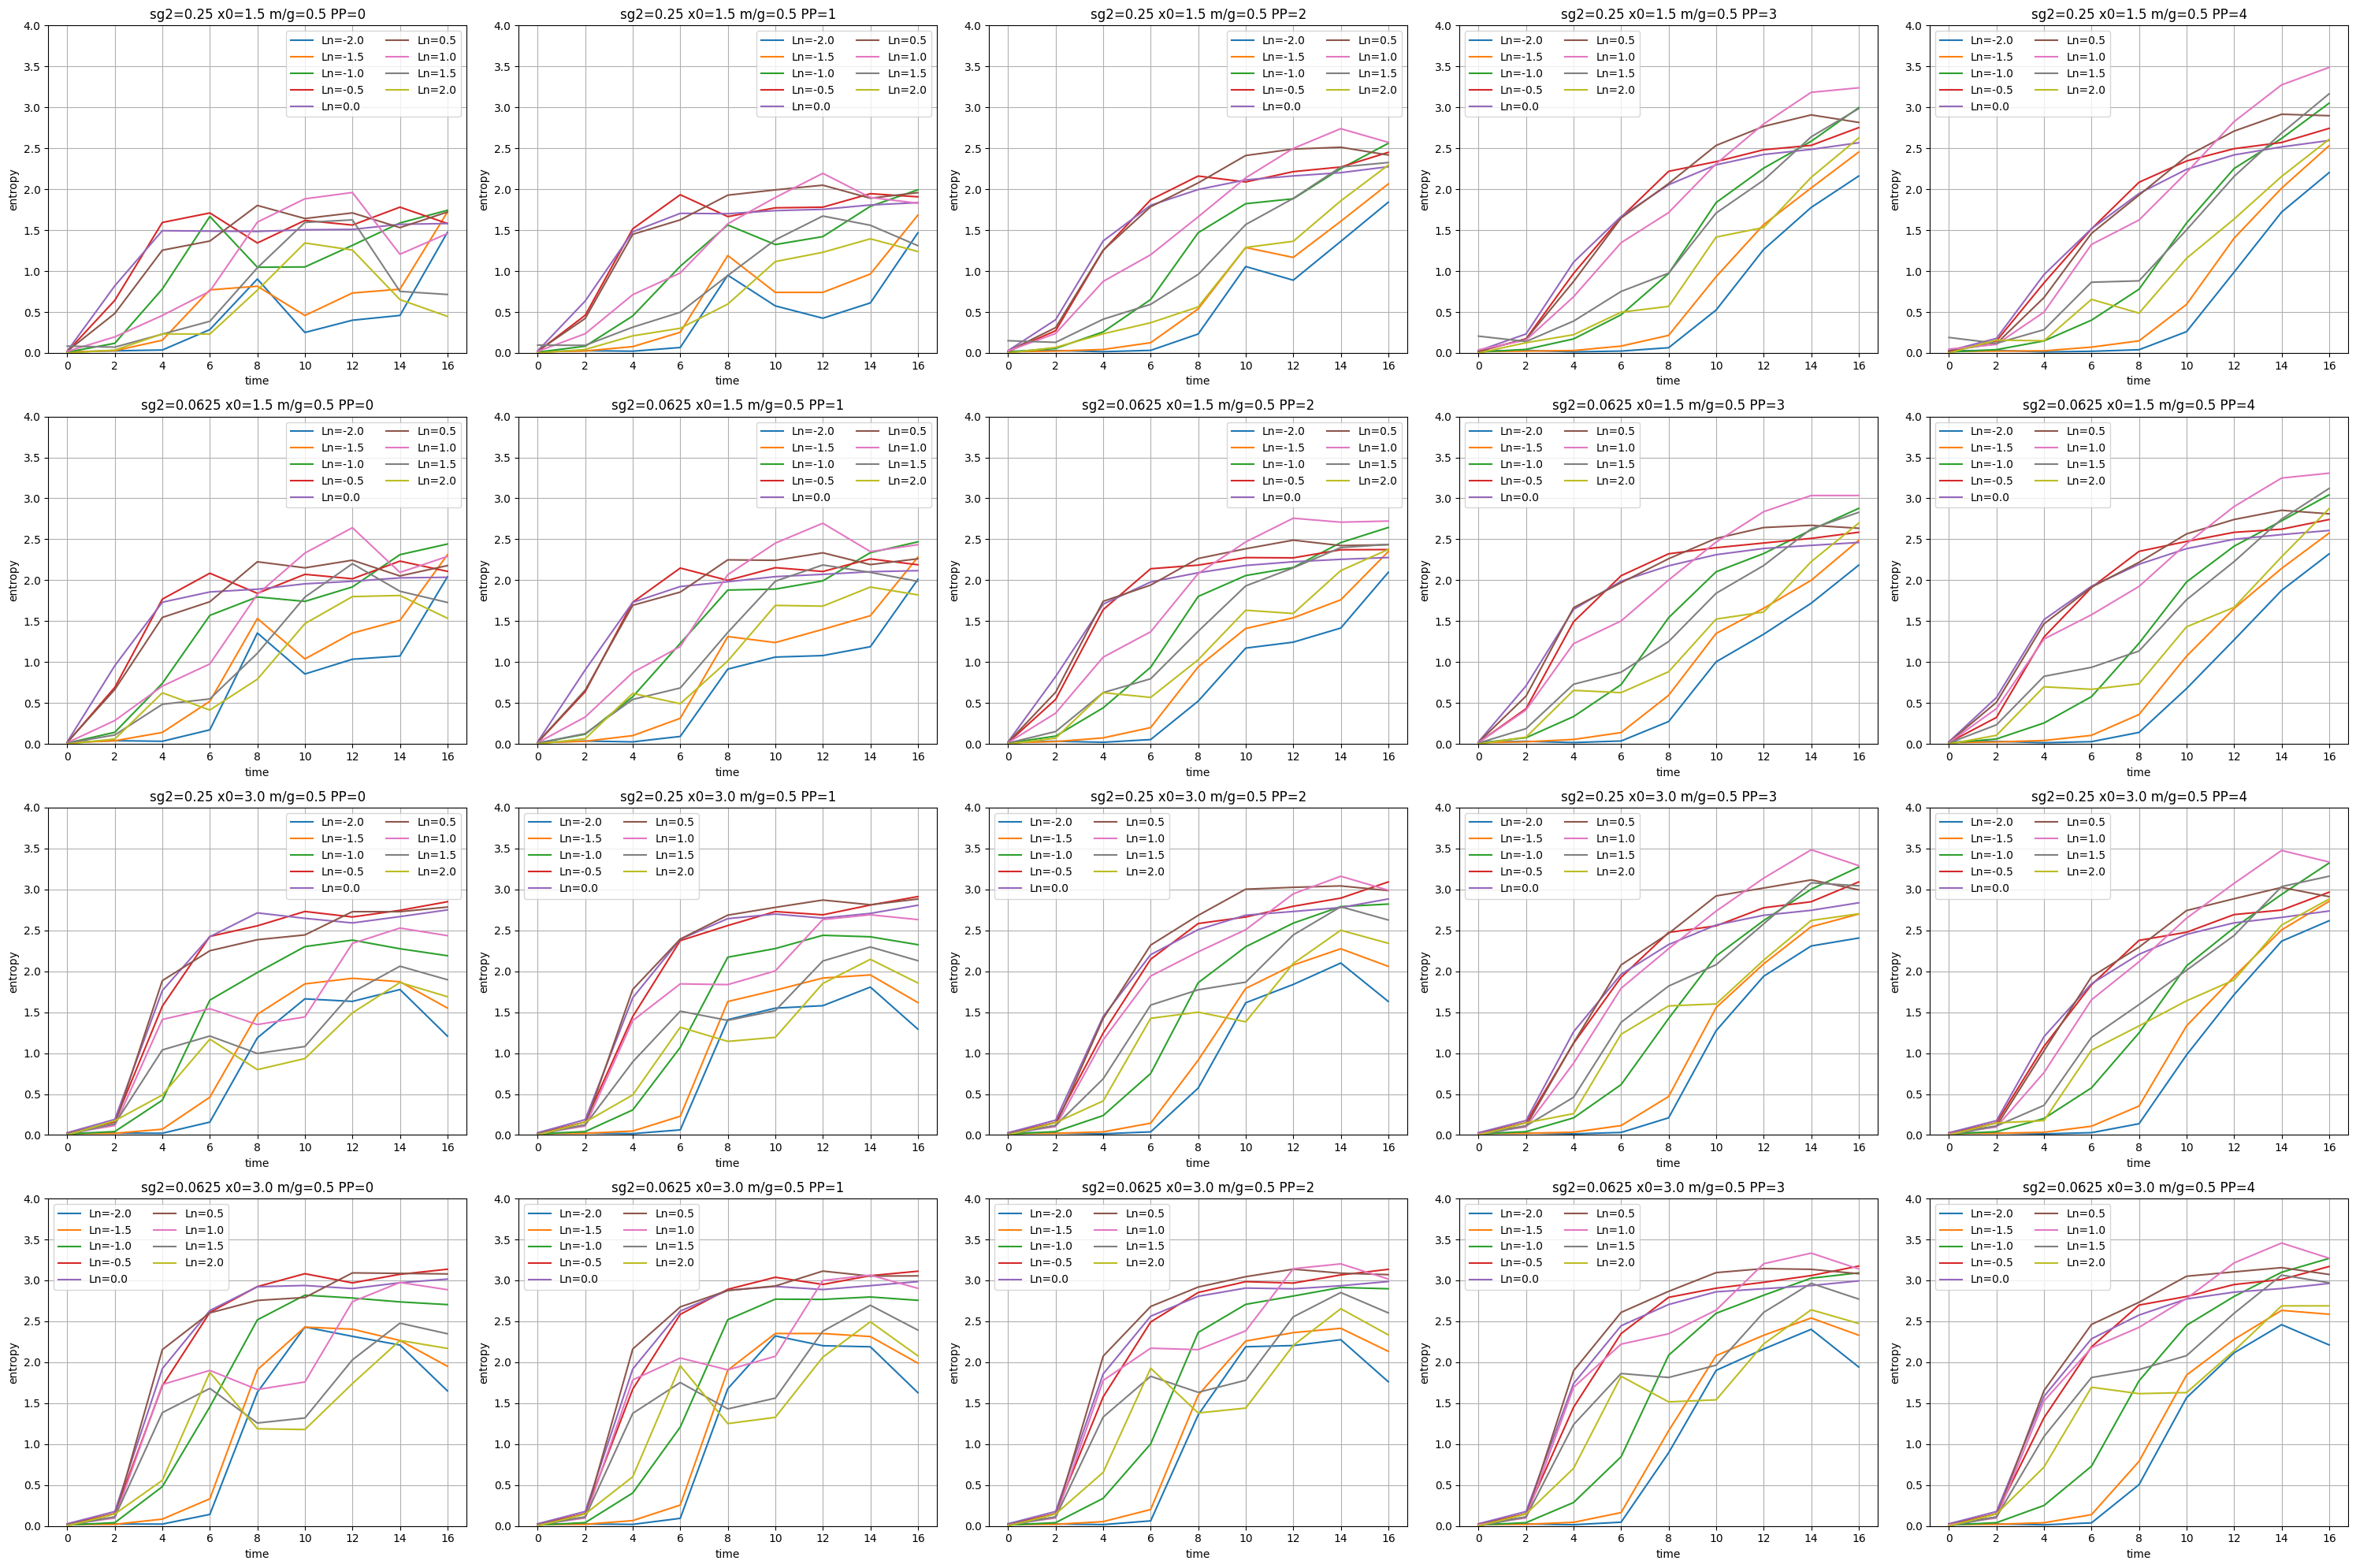

In [24]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]
PPs = np.linspace(0, 6, 49)

# sg2x0s = [(0.5, 1.5), (0.25, 1.5), (0.5, 3.0), (0.125, 1.5), (0.25, 3.0), (0.0625, 1.5), (0.125, 3.0), (0.0625, 3.0), (0.25, 6.0), (0.25, 9.0)]

sg2x0s = [(0.25, 1.5), (0.0625, 1.5), (0.25, 3.0), (0.0625, 3.0)]
Ps = [0, 1, 2, 3, 4]

D = 256
m = 0.5
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]
fig, axs = plt.subplots(len(sg2x0s), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(sg2x0s) * 5)
for ii, (sg2, x0) in enumerate(sg2x0s):
  for jj, PP in enumerate(Ps):
      tmp = get_ent(x0, sg2, m, PP, D, normalize=True)
      for kk, l in enumerate(LLs):
        axs[ii,jj].plot(ts[slc], tmp[slc, kk], label=f'Ln={l}')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 4)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('entropy')
      axs[ii,jj].set_title(f"{sg2=} {x0=} {m/g=} {PP=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


/tmp/ipykernel_59823/1062234162.py:19: RuntimeWarning: divide by zero encountered in log2
  axs[ii,jj].plot(ts, -np.log2(tmp), '-+', color='c')
/tmp/ipykernel_59823/1062234162.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[ii,jj].legend(ncols=2)


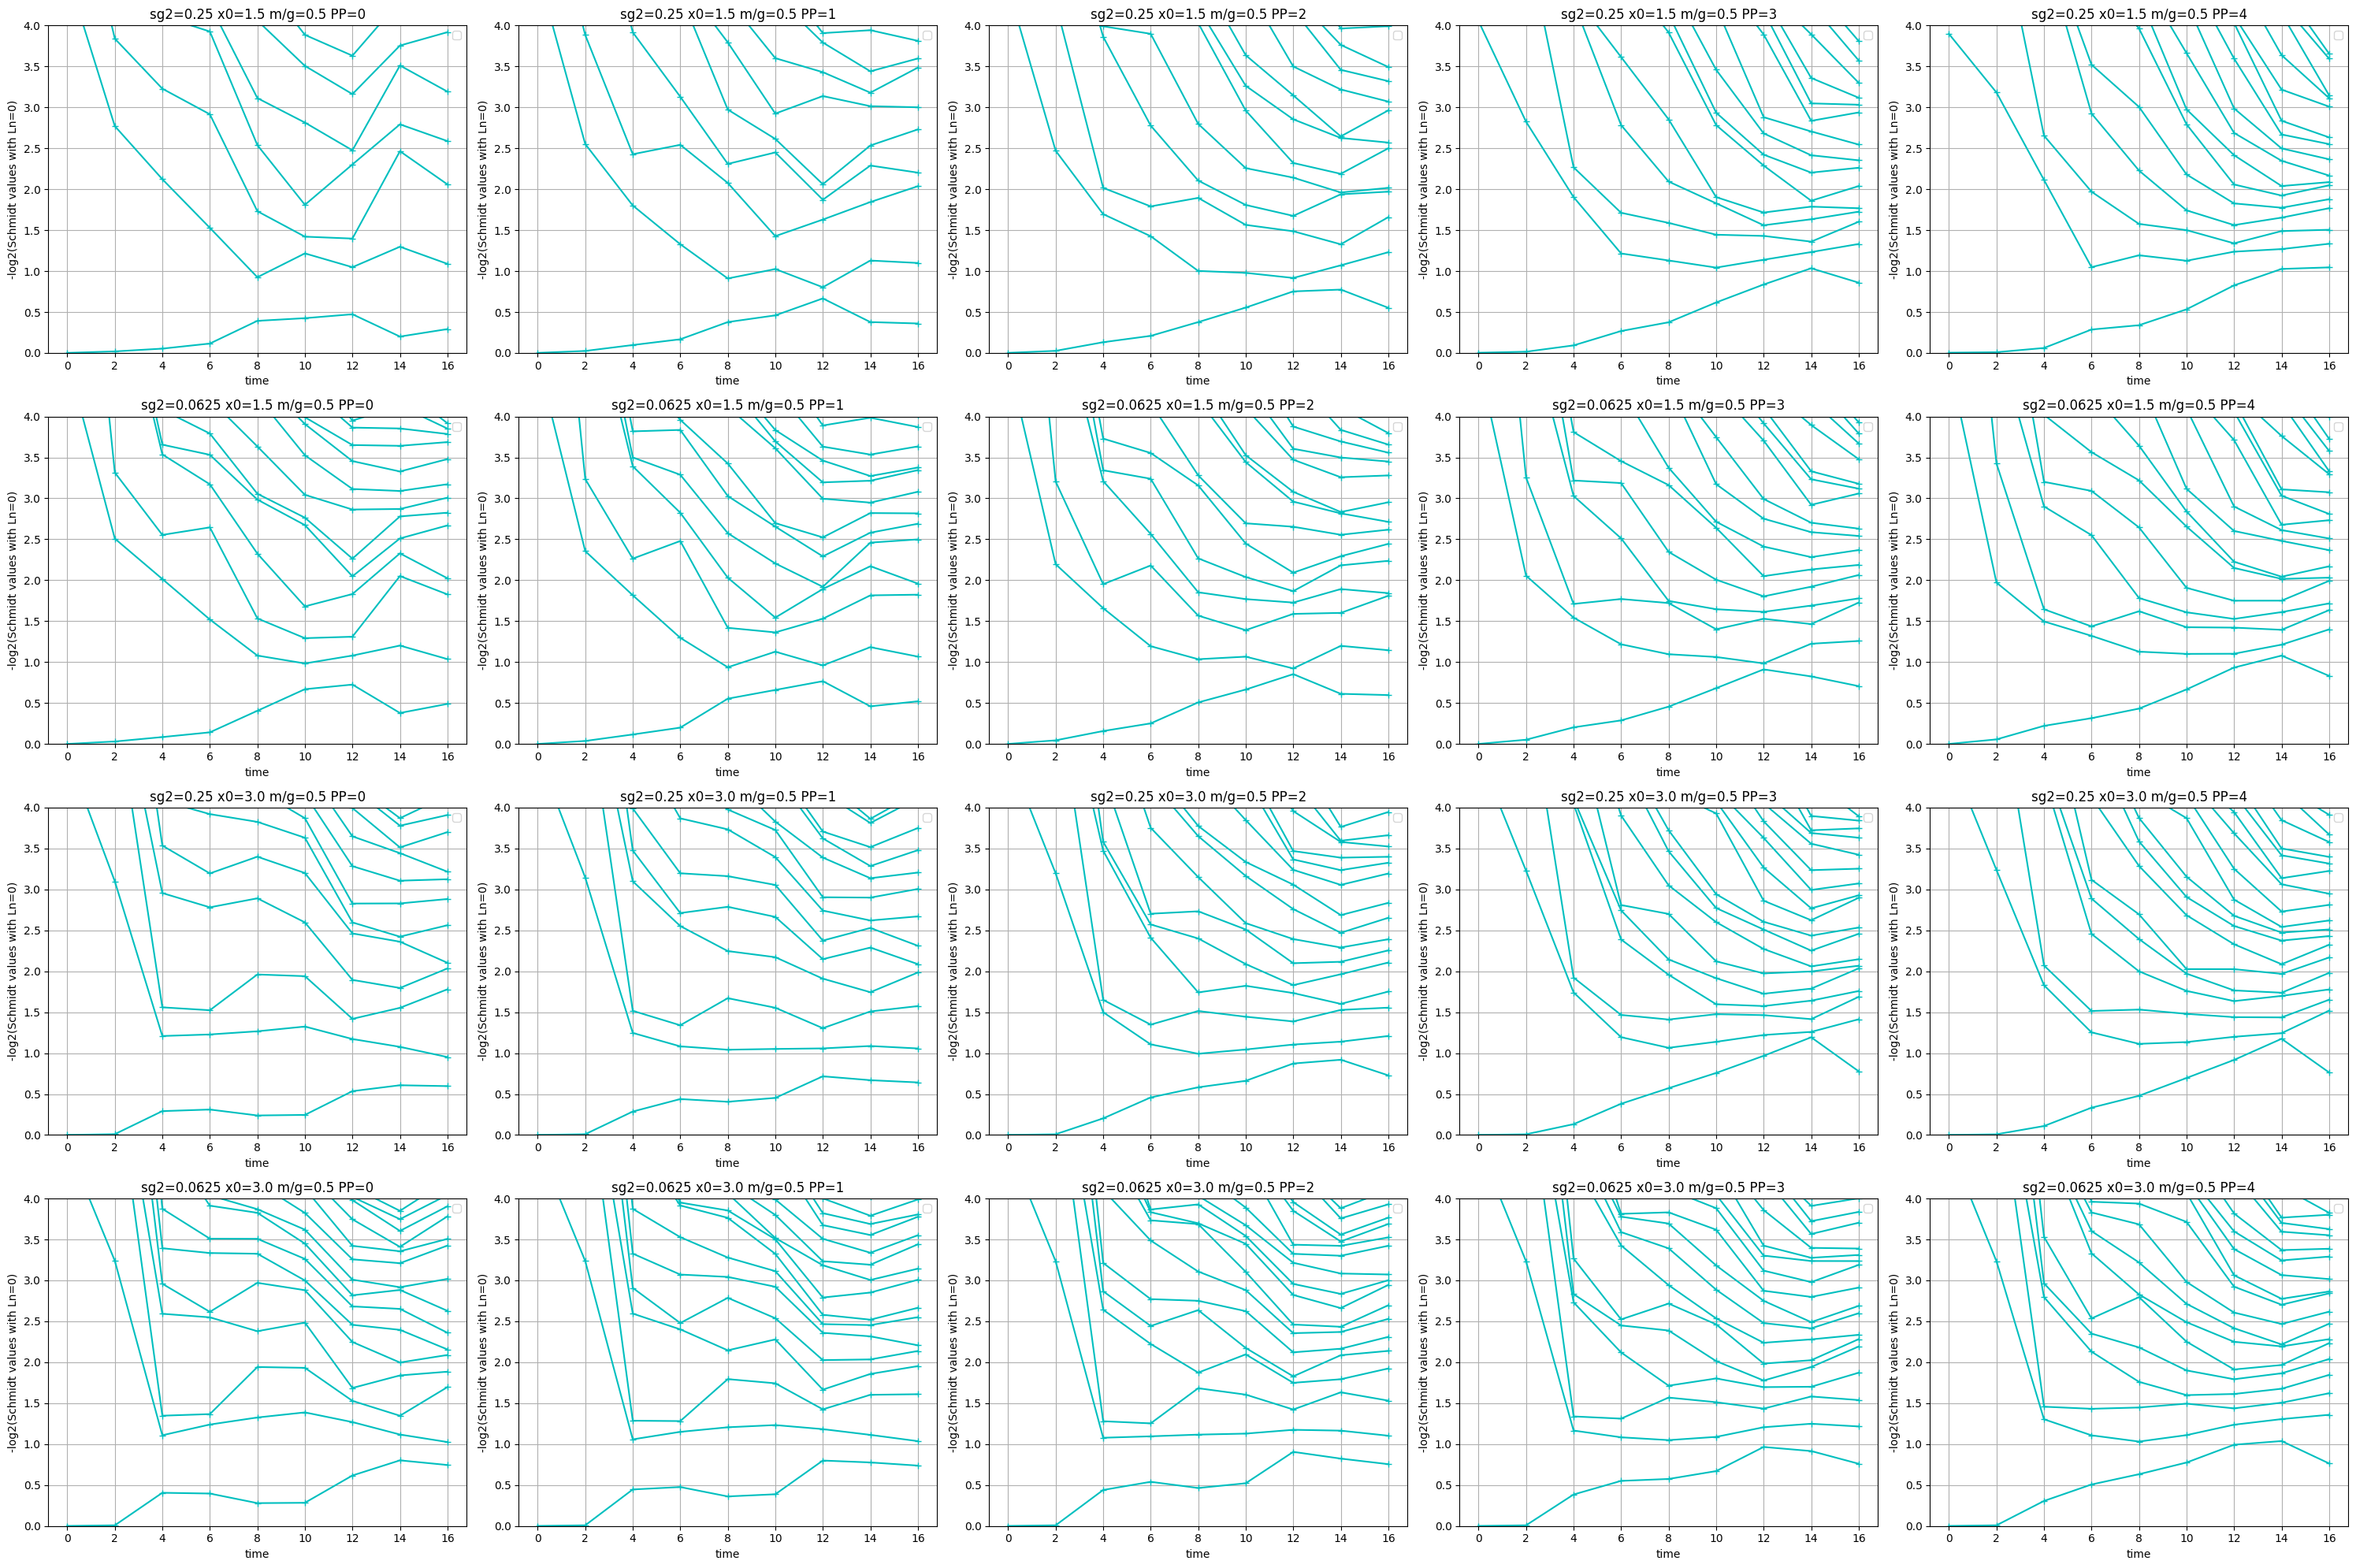

In [35]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]
PPs = np.linspace(0, 6, 49)

# sg2x0s = [(0.5, 1.5), (0.25, 1.5), (0.5, 3.0), (0.125, 1.5), (0.25, 3.0), (0.0625, 1.5), (0.125, 3.0), (0.0625, 3.0), (0.25, 6.0), (0.25, 9.0)]

sg2x0s = [(0.25, 1.5), (0.0625, 1.5), (0.25, 3.0), (0.0625, 3.0)]
Ps = [0, 1, 2, 3, 4]

D = 256
m = 0.5
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]
fig, axs = plt.subplots(len(sg2x0s), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(sg2x0s) * 5)
for ii, (sg2, x0) in enumerate(sg2x0s):
  for jj, PP in enumerate(Ps):
      tmp = get_sv(x0, sg2, m, PP, D, normalize=True, num=6)
      axs[ii,jj].plot(ts, -np.log2(tmp), '-+', color='c')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 4)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('-log2(Schmidt values with Ln=0)')
      axs[ii,jj].set_title(f"{sg2=} {x0=} {m/g=} {PP=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


In [ ]:
cm = plt.cm.jet
Ps = [0, 1, 2, 3, 4]
PPs = np.linspace(0, 6, 49)

# sg2x0s = [(0.5, 1.5), (0.25, 1.5), (0.5, 3.0), (0.125, 1.5), (0.25, 3.0), (0.0625, 1.5), (0.125, 3.0), (0.0625, 3.0), (0.25, 6.0), (0.25, 9.0)]

sg2x0s = [(0.25, 1.5), (0.0625, 1.5), (0.25, 3.0), (0.0625, 3.0)]
Ps = [0, 1, 2, 3, 4]

D = 256
m = 0.0
slc = slice(None)
#sg2x0s = [(0.5, 1.5), (0.5, 3.0), (0.25, 1.5), (0.25, 3.0),  (0.25, 6.0), (0.25, 9.0), (0.125, 1.5), (0.125, 3.0), (0.0625, 1.5), (0.0625, 3.0)]
fig, axs = plt.subplots(len(sg2x0s), len(Ps), squeeze=False)
fig.set_size_inches(len(Ps) * 6, len(sg2x0s) * 5)
for ii, (sg2, x0) in enumerate(sg2x0s):
  for jj, PP in enumerate(Ps):

      tmp = get_ent(x0, sg2, m, PP, D)
      for kk, l in enumerate(LLs):
        axs[ii,jj].plot(ts[slc], tmp[slc, kk], label=f'Ln={l}')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 3)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('probability')
      axs[ii,jj].set_title(f"{sg2=} {x0=} {m/g=} {PP=}")

#fig.suptitle("Overlap with Romuald's excited state construction; energy conserving")

plt.tight_layout()


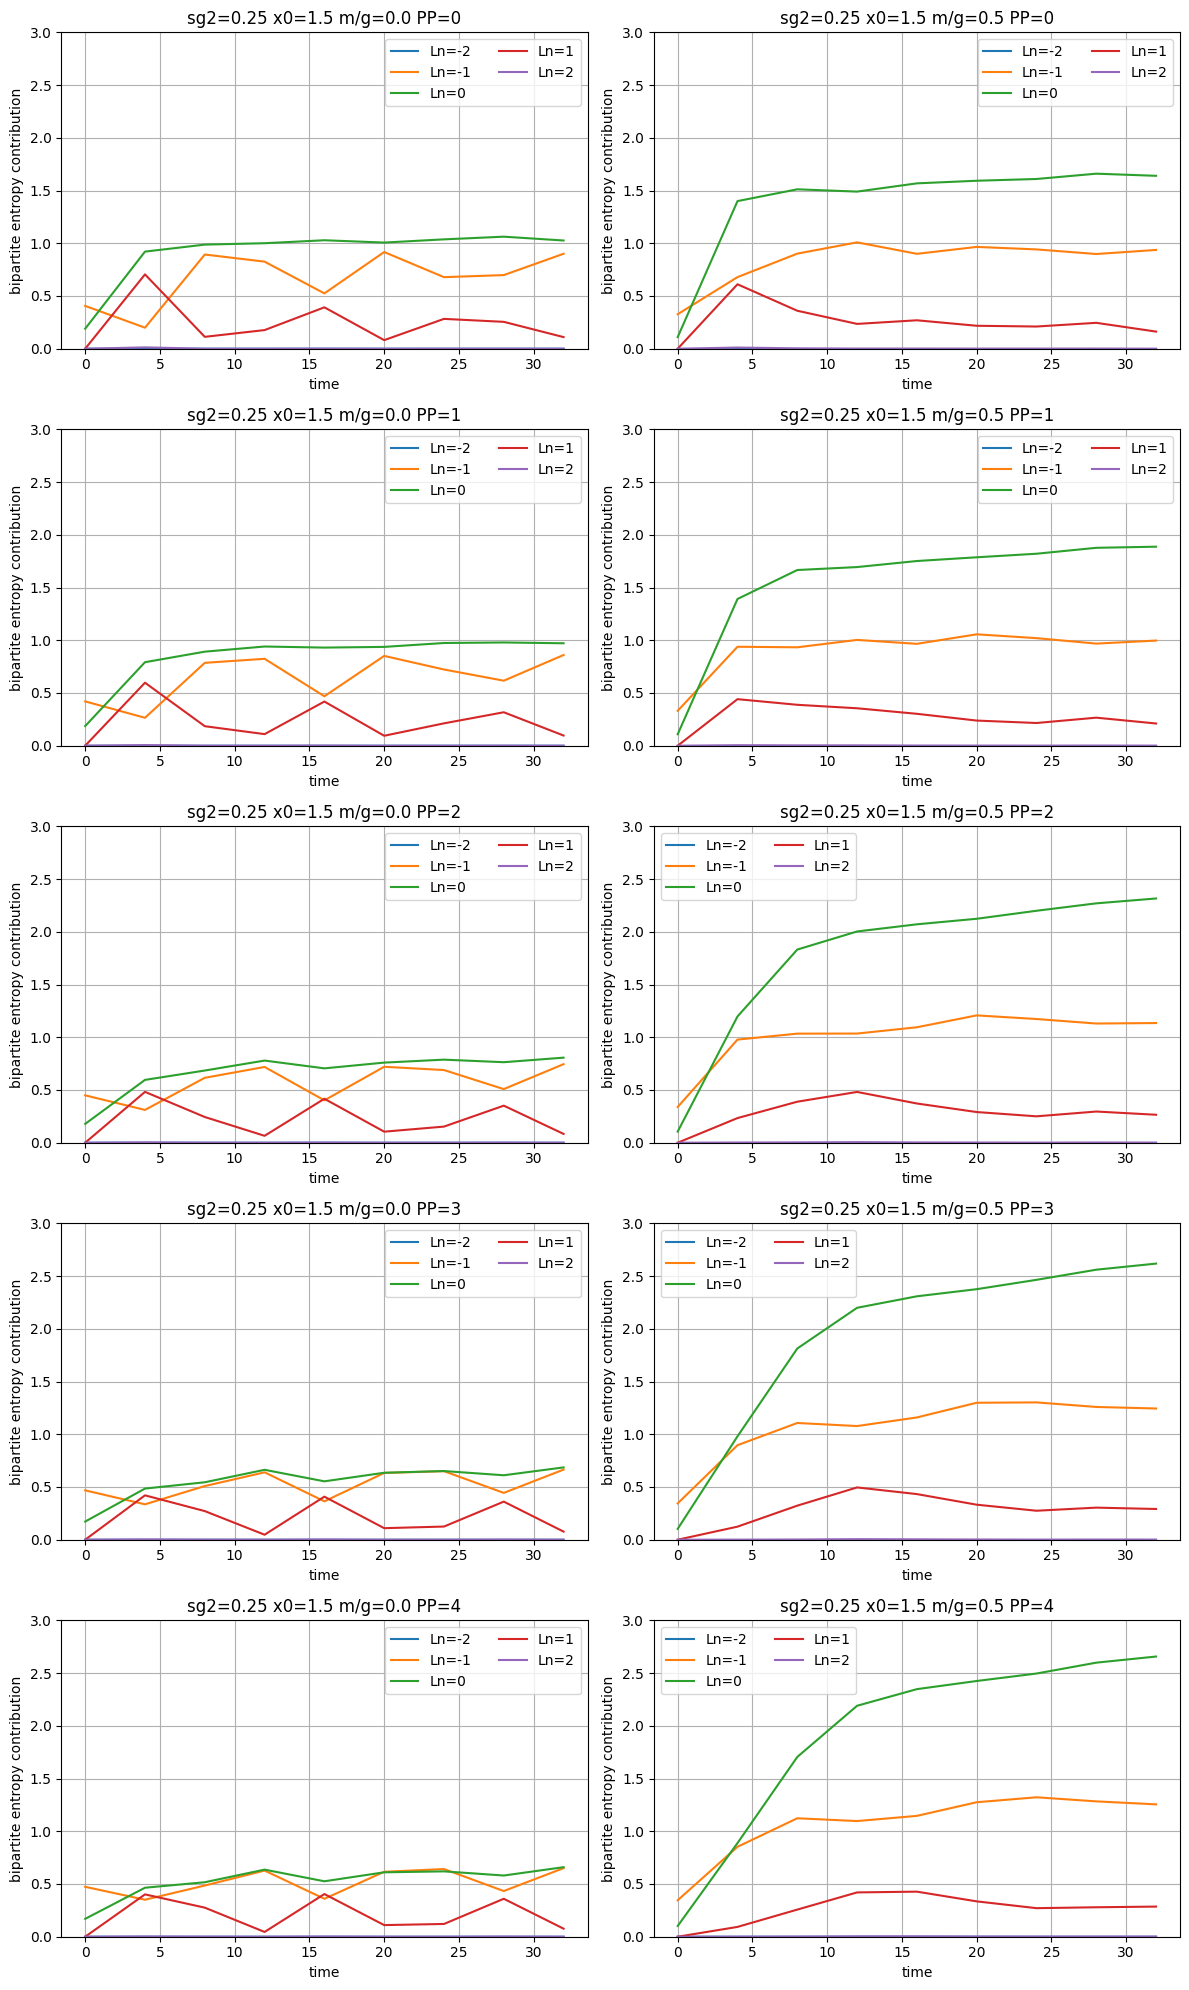

In [ ]:
cm = plt.cm.jet
fig, axs = plt.subplots(len(Ps), len(ms), squeeze=False)
fig.set_size_inches(len(ms) * 6, len(Ps) * 4)
slc = slice(None)

D = 512
for ii, PP in enumerate(Ps):
  for jj, m in enumerate(ms):
      pls_mid = get_dist(m, PP, D)
      for i, l in enumerate(LLLs):
        axs[ii,jj].plot(ts[slc], pls_mid[slc, i], label=f'Ln={l}')

      axs[ii,jj].legend(ncols=2)
      axs[ii,jj].set_ylim(0, 3)
      axs[ii,jj].grid()
      axs[ii,jj].set_xlabel('time')
      axs[ii,jj].set_ylabel('bipartite entropy contribution')
      axs[ii,jj].set_title(f"{sg2=} {x0=} {m/g=} {PP=}")

fig.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yastn
from yastn.tn import mps

import os
import glob

from scripts_fermions.operators import project_Ln, L_to_t, t_to_L
from sklearn.decomposition import PCA


from scipy.special import jv, gammaincc, gamma
from scipy.optimize import minimize

Nas = [(256, 0.125)] # [(256, 0.125), (512, 0.0625), (512, 0.125)]
ms = [0.5]
g = 1
sg2 = 0.25
x0 = 1.5
#
Ps = [0, ]
Ds = [256,]

def fn_mass(fns, **kwargs):
    return [x for x in fns if all( f"{k}={v}" in x for k, v in kwargs.items())][0]


N, a = Nas[0]
ts = np.linspace(0, N * a / 2, 9)
glob_path = os.path.join(os.path.abspath(""), "./results_fermions/g=1.0000/**/state_t=*.npy")
fnames = glob.glob(glob_path, recursive=True)
fns = sorted([fname for fname in fnames if all(x in fname for x in ["/g=1.0000/", "dt=0.0625", f"{N=}", f"{a=:0.4f}", f"{x0=:0.4f}", f"{sg2=:0.4f}"])])
psi_t = {}
for t in ts:
    for P in Ps:
        for D in Ds:
            for m in ms:
                psi_t[m, t, P, D] = yastn.from_dict(np.load(fn_mass(fns, m=m, t=t, P=P, D=D), allow_pickle=True).item()['psi'])

n0 = N // 2

def get_psiLn_pair(psi, n0=n0):
    # returns components of psi with (L(n0-1)+L(n0))/2 = -2, -3/2, -1, -1/2, 0, 1/2, 1, 3/2, 2
    assert n0 % 2 == 0

    psi2 = project_Ln(psi, 2, n0-1)
    psi1 = project_Ln(psi, 1, n0-1)
    psi0 = project_Ln(psi, 0, n0-1)
    psim1 = project_Ln(psi, -1, n0-1)
    psim2 = project_Ln(psi, -2, n0-1)

    assert project_Ln(psi2, 1, n0).norm() < 1e-10
    assert project_Ln(psi1, 0, n0).norm() < 1e-10
    assert project_Ln(psi0, -1, n0).norm() < 1e-10
    assert project_Ln(psim1, -2, n0).norm() < 1e-10

    psip4 = project_Ln(psi2, 2, n0)
    psip3 = project_Ln(psi1, 2, n0)
    psip2 = project_Ln(psi1, 1, n0)
    psip1 = project_Ln(psi0, 1, n0)
    psip0 = project_Ln(psi0, 0, n0)
    psipm1 = project_Ln(psim1, 0, n0)
    psipm2 = project_Ln(psim1, -1, n0)
    psipm3 = project_Ln(psim2, -1, n0)
    psipm4 = project_Ln(psim2, -2, n0)

    return [psipm4, psipm3, psipm2, psipm1, psip0, psip1, psip2, psip3, psip4]


# SVs = {}
# for k, v in psi_t.items():
#     print(k)
#     ww = v.get_Schmidt_values()[n0]

#     SVs[k] = {t_to_L(t, n0, N): ww[t].copy() for t in ww.get_blocks_charge()}




# fname = f"./SV_Gaussian_{N=}_{a=:0.4f}_{x0=:0.4f}_{sg2=:0.4f}.npy"
# np.save(fname, SVs)


In [ ]:
x.norm() ** 2

np.float64(0.46402689911236467)

In [ ]:
y = get_psiLn_pair(psi_t[0.5, 8.0, 0, 256])
x = y[4]

for n in range(0, n0):
    x.orthogonalize_site_(n=n, to='last', normalize=False)
    x.absorb_central_(to='last')

for n in range(N - 1, n0, -1):
    x.orthogonalize_site_(n=n, to='first', normalize=False)
    x.absorb_central_(to='first')

x[n0] = x[n0] * x.factor
x.factor = 1

SL = x[n0].svd(axes=(0, (1, 2)), compute_uv=False)
SR = x[n0].svd(axes=((0, 1), 2), compute_uv=False)

tl = SL.get_blocks_charge()[0][0]
tr = SR.get_blocks_charge()[0][0]
SL[tl, tl]

array([4.94743566e-01, 4.23754654e-01, 1.56699217e-01, 7.27653156e-02,
       6.66317589e-02, 4.83323536e-02, 2.97618817e-02, 2.54818038e-02,
       2.25833218e-02, 1.88999237e-02, 1.62377078e-02, 1.04500375e-02,
       7.96322307e-03, 7.81132568e-03, 6.13463694e-03, 5.41104693e-03,
       4.36902682e-03, 4.09838109e-03, 3.25807401e-03, 2.90776773e-03,
       2.53937421e-03, 2.34851331e-03, 2.20546957e-03, 1.92227546e-03,
       1.82749621e-03, 1.67614750e-03, 1.59906977e-03, 1.53860897e-03,
       1.30791728e-03, 1.08256582e-03, 1.07501343e-03, 9.82144850e-04,
       8.62540310e-04, 8.29078931e-04, 7.59927611e-04, 6.65595298e-04,
       6.00987248e-04, 5.43422422e-04, 4.74196747e-04, 4.34816493e-04,
       4.09645133e-04, 3.26118160e-04, 3.09489186e-04, 2.91057738e-04,
       2.70104782e-04, 2.49085886e-04, 2.25129688e-04, 2.01788848e-04,
       1.81594390e-04, 1.49675768e-04, 1.37640084e-04, 1.27613406e-04,
       1.17752274e-04, 1.07205529e-04, 1.01030340e-04, 9.29726765e-05,
      

In [ ]:
x[n0]

U1 s= (-1, 1, 1) n= (0,)
leg charges  : (((64,),), ((0,),), ((64,),))
dimensions   : ((72,), (1,), (76,))

In [ ]:

S = x[n0].svd(axes=(0, (1, 2)),  compute_uv=False)

In [ ]:
x.norm() ** 2

np.float64(0.46402689911236467)

In [ ]:
yastn.vdot(x[n0], x[n0])

np.complex128(0.013157894736842115+0j)

In [ ]:
a = yy.get_entropy()

(125.0, 134.0)

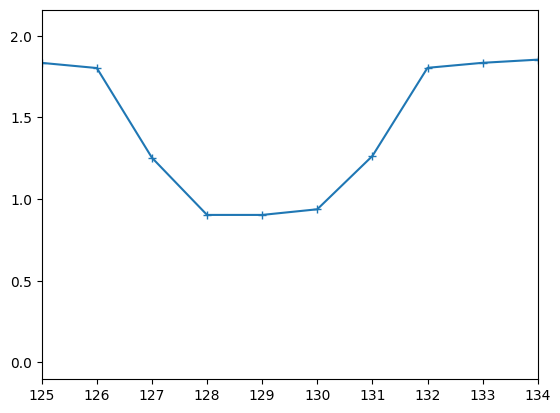

In [ ]:
plt.plot(a, '-+')
plt.xlim(125, 134)

In [ ]:
PRs[x0, sg2, m, PP, D, t][0]['SL']['struct']['t']

((66, 66),)

In [ ]:
PRs[x0, sg2, m, PP, D, t][0]['SL']['data']

array([1.29766101e-01, 6.77103409e-03, 3.01748075e-04, 2.29905146e-04,
       1.73975374e-05, 1.08413021e-05, 8.86804763e-06, 1.07809163e-06,
       5.95746490e-07, 5.16043121e-07])

In [ ]:
PRs[x0, sg2, m, PP, D, t][0]['SR']['struct']['t']

((66, 66),)

In [ ]:
PRs[x0, sg2, m, PP, D, t][0]['SR']['data']

array([1.29766101e-01, 6.77103409e-03, 3.01748075e-04, 2.29905146e-04,
       1.73975374e-05, 1.08413021e-05, 8.86804763e-06, 1.07809163e-06,
       5.95746490e-07, 5.16043121e-07])